# S&P 500 2000~2019 데이터 클렌징 및 다각도 분석

`SP500.csv`를 대상으로 날짜와 수치형 데이터를 정제한 뒤, 종가 추이, 수익률, 연도별 성과, 월별 패턴, 이동평균, 변동성, 최대 낙폭을 분석합니다.

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'

## 1. 원자료 불러오기 및 구조 확인

숫자에 천 단위 쉼표가 포함되어 있으므로 처음에는 모든 열을 문자열로 읽어 원본 구조를 확인합니다.

In [2]:
file_path = Path('SP500.csv')
if not file_path.exists():
    raise FileNotFoundError(f'{file_path.resolve()} 파일을 찾을 수 없습니다.')

raw = pd.read_csv(file_path, dtype=str)
print(f'원자료 크기: {raw.shape[0]:,}행 x {raw.shape[1]}열')
display(raw.head())
display(raw.dtypes.to_frame('dtype'))

원자료 크기: 5,000행 x 7열


,날짜,종가,시가,고가,저가,거래량,변동 %
0,2019- 11- 14,"3,096.60","3,090.80","3,098.20","3,083.30",NaN,0.08%
1,2019- 11- 13,"3,094.00","3,084.20","3,098.10","3,078.80",NaN,0.07%
2,2019- 11- 12,"3,091.80","3,089.30","3,102.60","3,084.70",NaN,0.16%
3,2019- 11- 11,"3,087.00","3,080.30","3,088.30","3,075.80",NaN,-0.20%
4,2019- 11- 08,"3,093.10","3,081.20","3,093.10","3,073.60",NaN,0.26%


,dtype
날짜,str
종가,str
시가,str
고가,str
저가,str
거래량,str
변동 %,str


## 2. 데이터 클렌징

- 날짜 내부의 공백을 제거하고 날짜형으로 변환합니다.
- 종가·시가·고가·저가의 천 단위 쉼표를 제거한 뒤 숫자형으로 변환합니다.
- 변동률의 `%` 기호를 제거하고 퍼센트 숫자로 변환합니다.
- 거래량처럼 전체가 결측인 열은 분석에서 제외합니다.
- 중복 날짜를 제거하고 2000-01-01부터 2019-12-31까지 필터링합니다.

In [3]:
df = raw.copy()

df['날짜'] = (
    df['날짜'].astype('string')
    .str.replace(r'\s+', '', regex=True)
    .pipe(pd.to_datetime, format='%Y-%m-%d', errors='coerce')
)

numeric_columns = ['종가', '시가', '고가', '저가']
for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column].astype('string').str.replace(',', '', regex=False),
        errors='coerce'
    )

df['변동 %'] = pd.to_numeric(
    df['변동 %'].astype('string').str.replace('%', '', regex=False),
    errors='coerce'
)

empty_columns = [column for column in df.columns if df[column].isna().all()]
if empty_columns:
    df = df.drop(columns=empty_columns)
    print(f'전체 결측 열 제거: {empty_columns}')

df = (
    df.dropna(subset=['날짜', '종가'])
      .drop_duplicates(subset='날짜', keep='last')
      .loc[lambda data: data['날짜'].between('2000-01-01', '2019-12-31')]
      .sort_values('날짜')
      .set_index('날짜')
)

print(f'정제 후 크기: {df.shape[0]:,}행 x {df.shape[1]}열')
print(f'분석 기간: {df.index.min().date()} ~ {df.index.max().date()}')
print(f'중복 날짜 수: {df.index.duplicated().sum()}')
display(df.head())
display(df.isna().sum().rename('결측치 수').to_frame())

전체 결측 열 제거: ['거래량']
정제 후 크기: 5,000행 x 5열
분석 기간: 2000-01-03 ~ 2019-11-14
중복 날짜 수: 0


,종가,시가,고가,저가,변동 %
날짜,,,,,
2000-01-03,"1,455.2000","1,469.2000","1,478.0000","1,438.4000",-0.9500
2000-01-04,"1,399.4000","1,455.2000","1,455.2000","1,397.4000",-3.8300
2000-01-05,"1,402.1000","1,399.4000","1,413.3000","1,377.7000",0.1900
2000-01-06,"1,403.5000","1,402.1000","1,411.9000","1,392.0000",0.1000
2000-01-07,"1,441.5000","1,403.5000","1,441.5000","1,400.5000",2.7100


,결측치 수
종가,0
시가,0
고가,0
저가,0
변동 %,0


## 3. 기초 통계와 파생 변수

일별 단순 수익률, 누적 수익률, 20일·60일 이동평균, 20일 연환산 변동성, 고점 대비 낙폭을 계산합니다.

In [4]:
df['일간 수익률'] = df['종가'].pct_change()
df['누적 수익률'] = (1 + df['일간 수익률'].fillna(0)).cumprod() - 1
df['20일 이동평균'] = df['종가'].rolling(20).mean()
df['60일 이동평균'] = df['종가'].rolling(60).mean()
df['20일 연환산 변동성'] = df['일간 수익률'].rolling(20).std() * np.sqrt(252)
df['고점'] = df['종가'].cummax()
df['낙폭'] = df['종가'] / df['고점'] - 1

summary = df[['종가', '시가', '고가', '저가', '일간 수익률']].describe().T
display(summary)

,count,mean,std,min,25%,50%,75%,max
종가,"5,000.0000","1,565.1812",574.2489,676.5000,"1,150.2750","1,358.2000","1,973.3750","3,096.6000"
시가,"5,000.0000","1,564.9905",574.1623,679.3000,"1,150.4500","1,358.0500","1,974.2750","3,090.8000"
고가,"5,000.0000","1,573.8936",574.9359,695.3000,"1,158.5250","1,366.9500","1,983.3750","3,102.6000"
저가,"5,000.0000","1,555.3756",573.2416,666.8000,"1,140.9500","1,347.0000","1,965.1500","3,084.7000"
일간 수익률,"4,999.0000",0.0002,0.0119,-0.0904,-0.0047,0.0005,0.0057,0.1159


## 4. 종가 기준 라인 그래프

장기 종가 추이와 단기 추세를 함께 확인합니다.

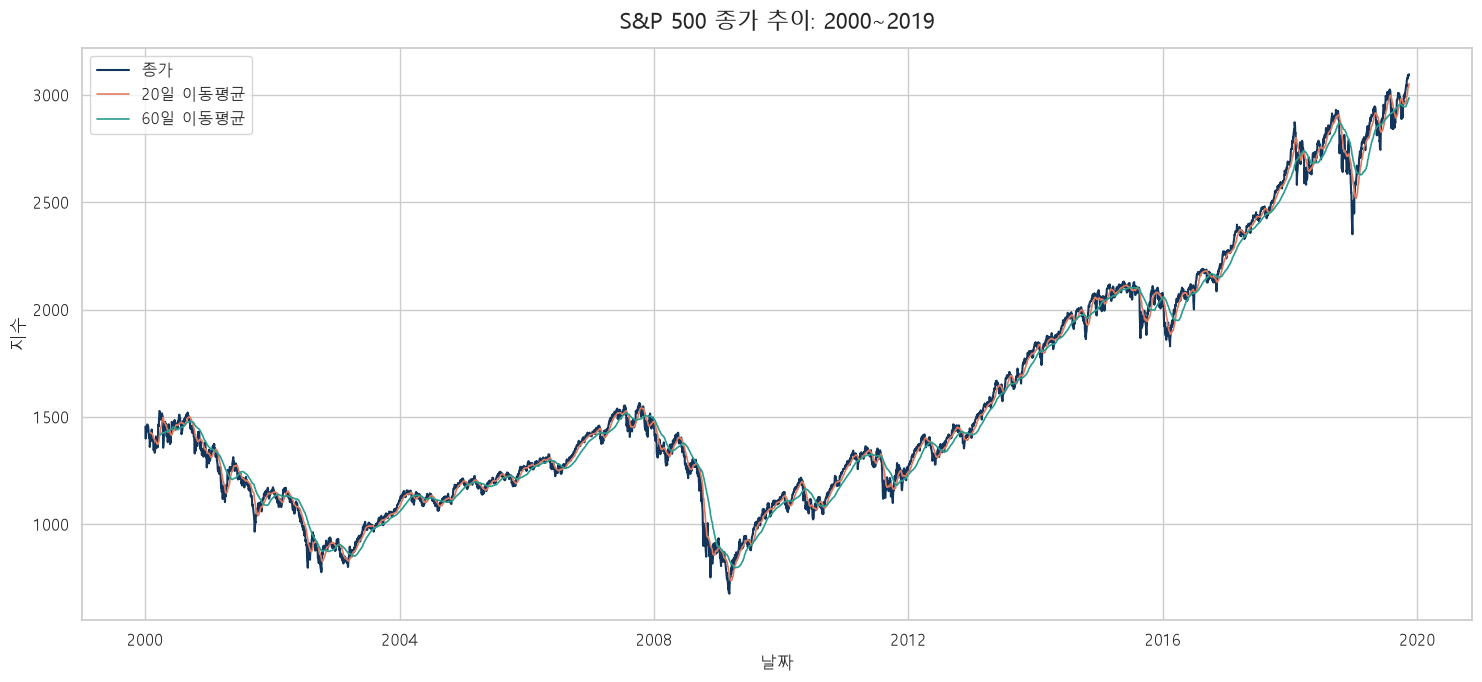

In [7]:
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(df.index, df['종가'], color='#12355B', linewidth=1.5, label='종가')
ax.plot(df.index, df['20일 이동평균'], color='#E07A5F', linewidth=1.2, label='20일 이동평균')
ax.plot(df.index, df['60일 이동평균'], color='#2A9D8F', linewidth=1.2, label='60일 이동평균')
ax.set_title('S&P 500 종가 추이: 2000~2019', fontsize=16, pad=14)
ax.set_xlabel('날짜')
ax.set_ylabel('지수')
ax.legend()
plt.tight_layout()
plt.show()

## 5. 연도별 성과 분석

,시작 종가,마지막 종가,평균 종가,거래일수,연간 최고가,연간 최저가,일간 변동성,연간 수익률,연환산 변동성
날짜,,,,,,,,,
2000,"1,455.2000","1,320.3000","1,427.2200",252,"1,553.1000","1,254.1000",0.0100,-9.2700,22.2400
2001,"1,283.3000","1,148.1000","1,194.1800",248,"1,383.4000",944.8000,0.0100,-10.5400,21.5500
2002,"1,154.7000",879.8000,993.9400,252,"1,177.0000",768.6000,0.0200,-23.8100,26.0300
2003,909.0000,"1,111.9000",965.2300,252,"1,112.6000",788.9000,0.0100,22.3200,17.0700
2004,"1,108.5000","1,211.9000","1,130.6500",252,"1,217.3000","1,060.7000",0.0100,9.3300,11.1000
2005,"1,202.1000","1,248.3000","1,207.2300",252,"1,275.8000","1,136.2000",0.0100,3.8400,10.2900
2006,"1,268.8000","1,418.3000","1,310.4600",251,"1,431.8000","1,219.3000",0.0100,11.7800,10.0400
2007,"1,416.6000","1,468.4000","1,477.1900",251,"1,576.1000","1,364.0000",0.0100,3.6600,15.9800
2008,"1,447.2000",903.2000,"1,220.0400",253,"1,471.8000",741.0000,0.0300,-37.5900,40.9700


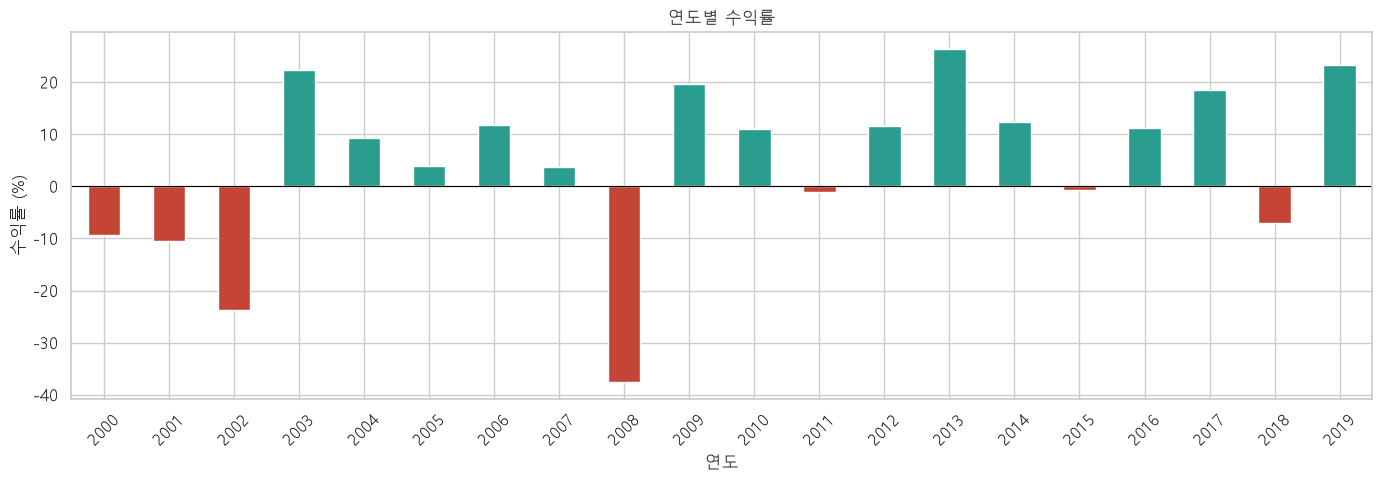

In [10]:
annual = df.groupby(df.index.year).agg({
    '종가': ['first', 'last', 'mean', 'count'],
    '고가': 'max',
    '저가': 'min',
    '일간 수익률': 'std',
})
annual.columns = ['시작 종가', '마지막 종가', '평균 종가', '거래일수', '연간 최고가', '연간 최저가', '일간 변동성']
annual['연간 수익률'] = annual['마지막 종가'] / annual['시작 종가'] - 1
annual['연환산 변동성'] = annual['일간 변동성'] * np.sqrt(252)
annual['연간 수익률'] = annual['연간 수익률'] * 100
annual['연환산 변동성'] = annual['연환산 변동성'] * 100
display(annual.round(2))

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#C44536' if value < 0 else '#2A9D8F' for value in annual['연간 수익률']]
annual['연간 수익률'].plot(kind='bar', color=colors, ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('연도별 수익률')
ax.set_xlabel('연도')
ax.set_ylabel('수익률 (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. 월별 수익률과 계절성

월,1,2,3,4,5,6,7,8,9,10,11,12
연도,,,,,,,,,,,,
2000,NaN,-2.0200,9.6800,-3.0800,-2.1900,2.3900,-1.6400,6.0700,-5.3500,-0.4900,-8.0000,0.4000
2001,3.4600,-9.2300,-6.4200,7.6900,0.5000,-2.5000,-1.0800,-6.4100,-8.1800,1.8200,7.5200,0.7500
2002,-1.5600,-2.0800,3.6800,-6.1400,-0.9100,-7.2400,-7.9000,0.4900,-11.0000,8.6500,5.7000,-6.0300
2003,-2.7400,-1.7100,0.8400,8.1000,5.0900,1.1300,1.6200,1.7900,-1.1900,5.4900,0.7100,5.0700
2004,1.7300,1.2200,-1.6300,-1.6800,1.2100,1.7900,-3.4300,0.2300,0.9400,1.4000,3.8600,3.2500
2005,-2.5200,1.8900,-1.9100,-2.0200,3.0000,-0.0200,3.6000,-1.1300,0.7000,-1.7700,3.5200,-0.1000
2006,2.5500,0.0500,1.1000,1.2200,-3.0900,0.0100,0.5100,2.1200,2.4500,3.1500,1.6500,1.2600
2007,1.4000,-2.1800,1.0000,4.3300,3.2500,-1.7800,-3.1900,1.2800,3.5800,1.4800,-4.4100,-0.8600
2008,-6.1200,-3.4700,-0.5900,4.7600,1.0700,-8.6000,-0.9800,1.2200,-9.0700,-16.9400,-7.4900,0.7800


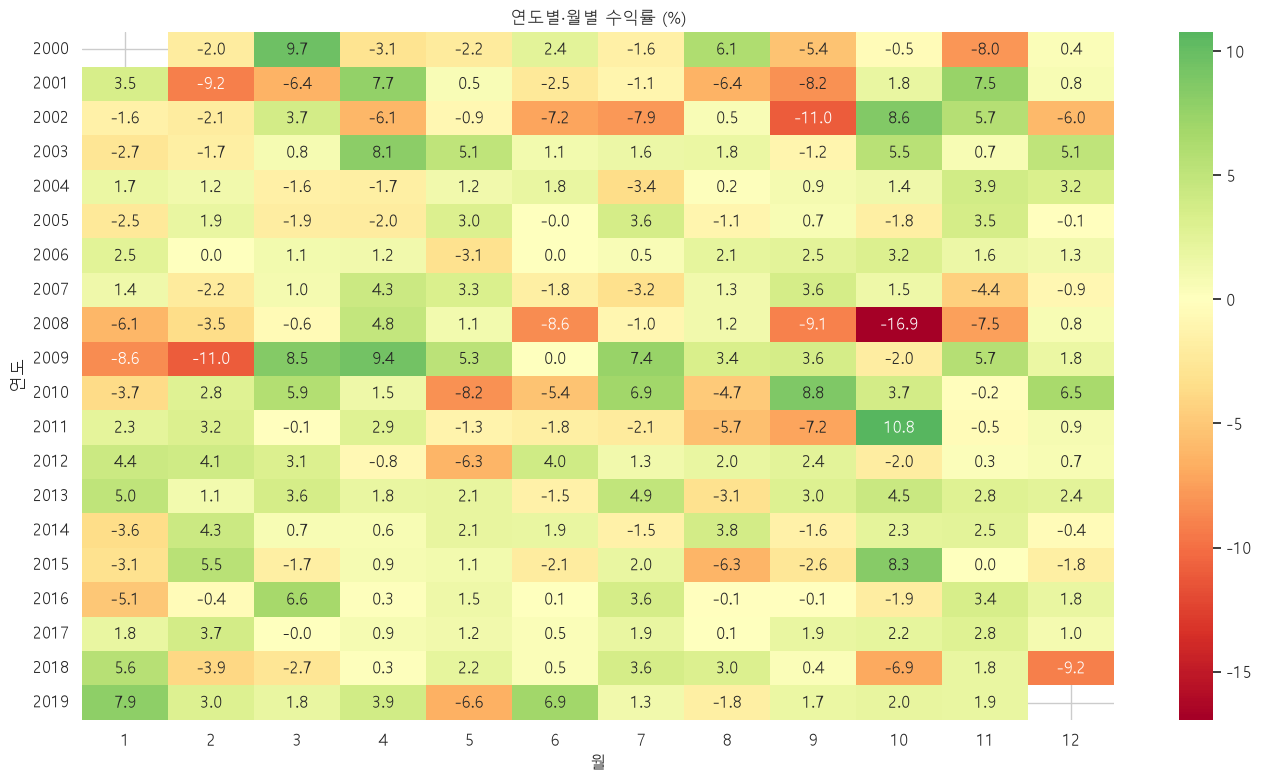

In [12]:
monthly = df['종가'].resample('ME').last().pct_change().dropna()
monthly_table = monthly.to_frame('월간 수익률')
monthly_table['연도'] = monthly_table.index.year
monthly_table['월'] = monthly_table.index.month
monthly_pivot = monthly_table.pivot(index='연도', columns='월', values='월간 수익률').astype('float64') * 100

display(monthly_pivot.round(2))

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(monthly_pivot, cmap='RdYlGn', center=0, annot=True, fmt='.1f', ax=ax)
ax.set_title('연도별·월별 수익률 (%)')
ax.set_xlabel('월')
ax.set_ylabel('연도')
plt.tight_layout()
plt.show()

## 7. 변동성과 최대 낙폭(Drawdown)

## 8. 분석 요약 지표

최대 낙폭: -56.78%
고점 날짜/종가: 2007-10-09 / 1,565.20
저점 날짜/종가: 2009-03-09 / 676.50


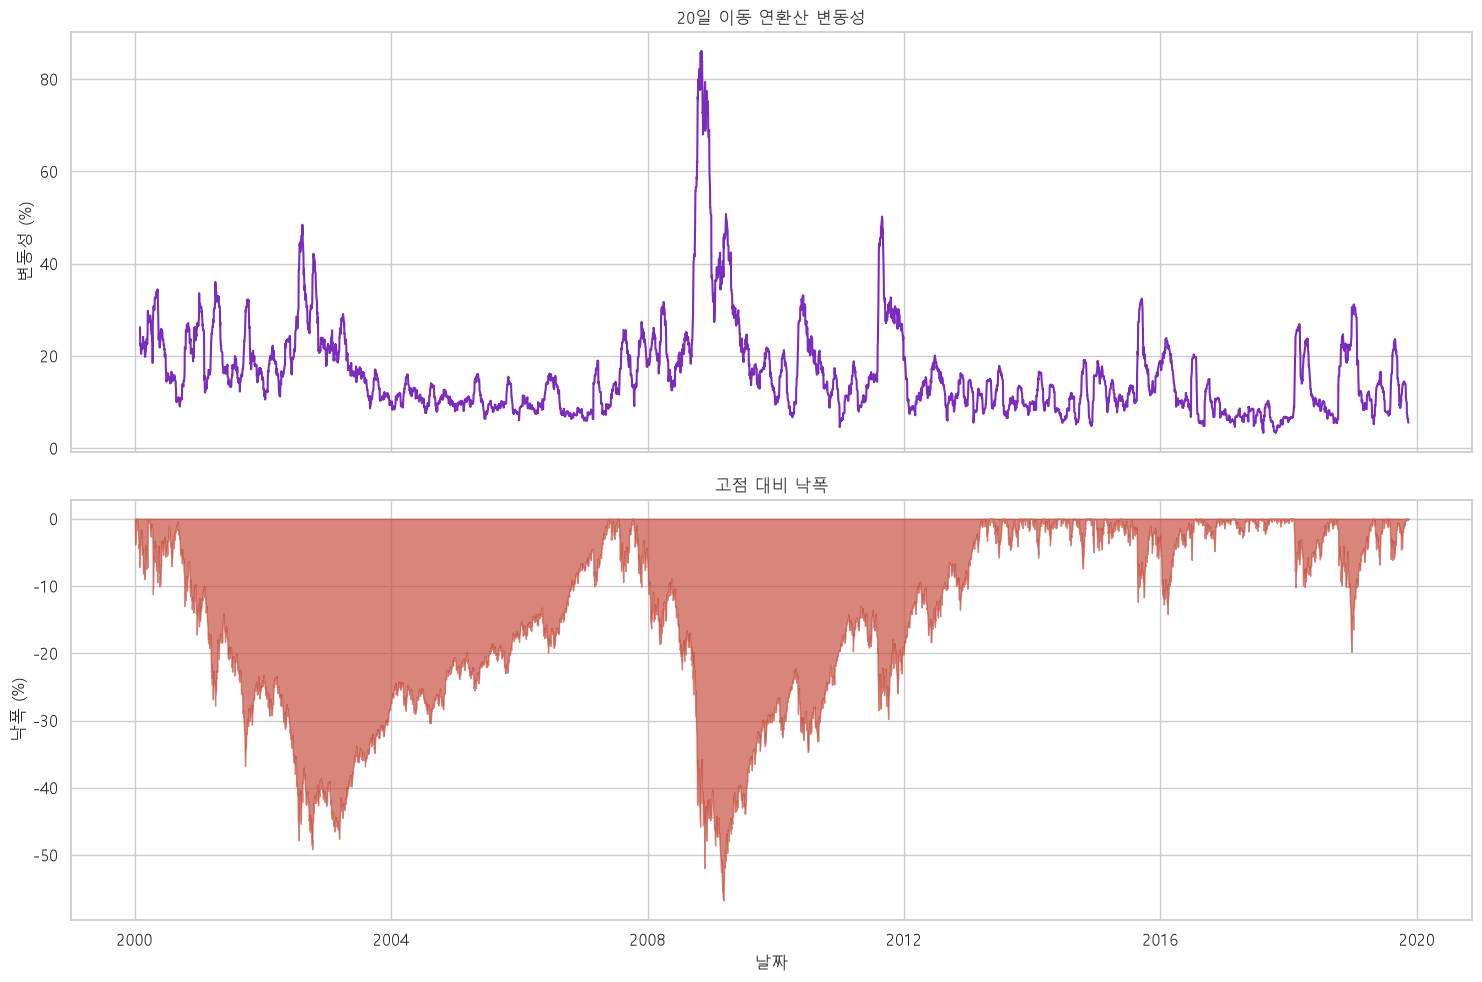

In [13]:
max_drawdown_date = df['낙폭'].idxmin()
max_drawdown = df.loc[max_drawdown_date, '낙폭']
peak_date = df.loc[:max_drawdown_date, '종가'].idxmax()
peak_value = df.loc[peak_date, '종가']
trough_value = df.loc[max_drawdown_date, '종가']

print(f'최대 낙폭: {max_drawdown:.2%}')
print(f'고점 날짜/종가: {peak_date.date()} / {peak_value:,.2f}')
print(f'저점 날짜/종가: {max_drawdown_date.date()} / {trough_value:,.2f}')

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
axes[0].plot(df.index, df['20일 연환산 변동성'] * 100, color='#7B2CBF')
axes[0].set_title('20일 이동 연환산 변동성')
axes[0].set_ylabel('변동성 (%)')
axes[1].fill_between(df.index, df['낙폭'] * 100, 0, color='#C44536', alpha=0.65)
axes[1].set_title('고점 대비 낙폭')
axes[1].set_ylabel('낙폭 (%)')
axes[1].set_xlabel('날짜')
plt.tight_layout()
plt.show()

In [14]:
total_return = df['종가'].iloc[-1] / df['종가'].iloc[0] - 1
annualized_return = (1 + total_return) ** (252 / max(len(df) - 1, 1)) - 1
positive_days = (df['일간 수익률'] > 0).mean()

result = pd.Series({
    '분석 시작일': df.index.min().date(),
    '분석 종료일': df.index.max().date(),
    '거래일 수': len(df),
    '기간 누적 수익률': total_return,
    '연환산 수익률': annualized_return,
    '일간 상승 비율': positive_days,
    '최대 낙폭': max_drawdown,
    '최대 종가': df['종가'].max(),
    '최저 종가': df['종가'].min(),
})
display(result.to_frame('값'))
print('참고: 원본 CSV의 실제 마지막 날짜가 2019년 11월이라 2019년 12월 데이터는 포함되지 않습니다.')

,값
분석 시작일,2000-01-03
분석 종료일,2019-11-14
거래일 수,5000
기간 누적 수익률,1.1280
연환산 수익률,0.0388
일간 상승 비율,0.5315
최대 낙폭,-0.5678
최대 종가,"3,096.6000"
최저 종가,676.5000


참고: 원본 CSV의 실제 마지막 날짜가 2019년 11월이라 2019년 12월 데이터는 포함되지 않습니다.
